<a href="https://colab.research.google.com/github/sanjana-budha/data-analytics/blob/main/prescriptiveanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      Name  Age Condition  Oxygen
0     Ravi   72  Critical      78
1     Sita   50   Serious      89
2     Arun   25    Stable      96
3    Kiran   65  Critical      82
4    Meena   45   Serious      90
5    Rahul   30    Stable      95
6   Anjali   55  Critical      84
7    Vijay   38   Serious      91
8    Priya   22    Stable      98
9  Lakshmi   68  Critical      79
Patients Allocated Beds

Ravi -> Bed Allocated
Prescription : ICU Bed + Oxygen Support

Kiran -> Bed Allocated
Prescription : ICU Bed + Oxygen Support

Lakshmi -> Bed Allocated
Prescription : ICU Bed + Oxygen Support

Anjali -> Bed Allocated
Prescription : ICU Bed + Oxygen Support

Sita -> Bed Allocated
Prescription : General Bed + Monitoring

Patients Waiting

Meena -> Waiting
Vijay -> Waiting
Arun -> Waiting
Rahul -> Waiting
Priya -> Waiting


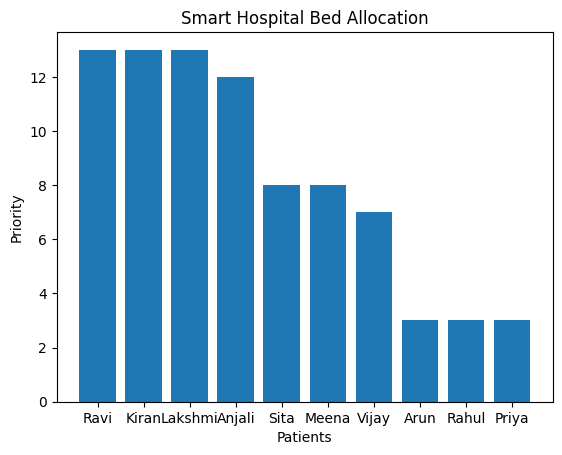

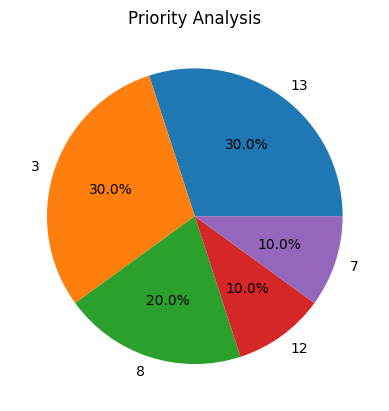

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Name": ["Ravi", "Sita", "Arun", "Kiran", "Meena",
             "Rahul", "Anjali", "Vijay", "Priya", "Lakshmi"],

    "Age": [72, 50, 25, 65, 45, 30, 55, 38, 22, 68],

    "Condition": ["Critical", "Serious", "Stable", "Critical", "Serious",
                  "Stable", "Critical", "Serious", "Stable", "Critical"],

    "Oxygen": [78, 89, 96, 82, 90, 95, 84, 91, 98, 79]
}

df = pd.DataFrame(data)
print(df)
priority = []

for i in range(len(df)):

    p = 0

    if df["Age"][i] > 60:
        p += 3
    elif df["Age"][i] >= 40:
        p += 2
    else:
        p += 1

    if df["Condition"][i] == "Critical":
        p += 5
    elif df["Condition"][i] == "Serious":
        p += 3
    else:
        p += 1

    if df["Oxygen"][i] < 85:
        p += 5
    elif df["Oxygen"][i] <= 92:
        p += 3
    else:
        p += 1

    priority.append(p)

df["Priority"] = priority

df = df.sort_values(by="Priority", ascending=False)

available_beds = 5

print("Patients Allocated Beds\n")

for i in range(available_beds):

    print(df.iloc[i]["Name"], "-> Bed Allocated")

    if df.iloc[i]["Priority"] >= 10:
        print("Prescription : ICU Bed + Oxygen Support")

    else:
        print("Prescription : General Bed + Monitoring")

    print()

print("Patients Waiting\n")

for i in range(available_beds, len(df)):
    print(df.iloc[i]["Name"], "-> Waiting")

plt.bar(df["Name"], df["Priority"])
plt.xlabel("Patients")
plt.ylabel("Priority")
plt.title("Smart Hospital Bed Allocation")
plt.show()

plt.pie(df["Priority"].value_counts(), labels=df["Priority"].value_counts().index.astype(str), autopct="%1.1f%%")
plt.title("Priority Analysis")
plt.show()

Patients Allocated Beds

Ravi -> ICU Bed
Sita -> General Bed
Kiran -> ICU Bed
Meena -> General Bed
Anjali -> ICU Bed

Patients Waiting

Arun -> Waiting
Rahul -> Waiting
Priya -> Waiting


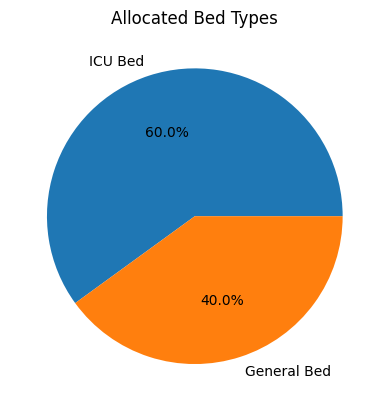

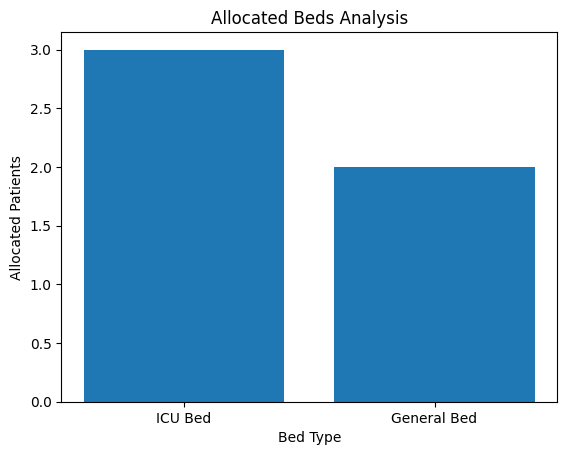

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Name": ["Ravi", "Sita", "Arun", "Kiran", "Meena",
             "Rahul", "Anjali", "Vijay", "Priya", "Lakshmi"],

    "Age": [72, 50, 25, 65, 45, 30, 55, 38, 22, 68],

    "Condition": ["Critical", "Serious", "Stable", "Critical", "Serious",
                  "Stable", "Critical", "Serious", "Stable", "Critical"],

    "Oxygen": [78, 89, 96, 82, 90, 95, 84, 91, 98, 79]
}

df = pd.DataFrame(data)

prescription = []

for i in range(len(df)):

    if df["Condition"][i] == "Critical" and df["Oxygen"][i] < 85:
        prescription.append("ICU Bed")

    elif df["Condition"][i] == "Serious" and df["Oxygen"][i] <= 92:
        prescription.append("General Bed")

    else:
        prescription.append("Home Care")

df["Prescription"] = prescription

available_beds = 5

allocated = []

print("Patients Allocated Beds\n")

count = 0

for i in range(len(df)):

    if count < available_beds:

        if df["Prescription"][i] != "Home Care":

            print(df["Name"][i], "->", df["Prescription"][i])

            allocated.append(df["Prescription"][i])

            count += 1

print("\nPatients Waiting\n")

for i in range(len(df)):

    if df["Prescription"][i] == "Home Care":

        print(df["Name"][i], "-> Waiting")

counts = pd.Series(allocated).value_counts()

plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
plt.title("Allocated Bed Types")
plt.show()

plt.bar(counts.index, counts.values)
plt.xlabel("Bed Type")
plt.ylabel("Allocated Patients")
plt.title("Allocated Beds Analysis")
plt.show()

      Name  Age Condition  Oxygen Prescription
0     Ravi   72  Critical      78      ICU Bed
1     Sita   50   Serious      89  General Bed
2     Arun   25    Stable      96    Home Care
3    Kiran   65  Critical      82      ICU Bed
4    Meena   45   Serious      90  General Bed
5    Rahul   30    Stable      95    Home Care
6   Anjali   55  Critical      84      ICU Bed
7    Vijay   38   Serious      91  General Bed
8    Priya   22    Stable      98    Home Care
9  Lakshmi   68  Critical      79      ICU Bed

Prescription Analysis

Ravi -> ICU Bed
Sita -> General Bed
Arun -> Home Care
Kiran -> ICU Bed
Meena -> General Bed
Rahul -> Home Care
Anjali -> ICU Bed
Vijay -> General Bed
Priya -> Home Care
Lakshmi -> ICU Bed


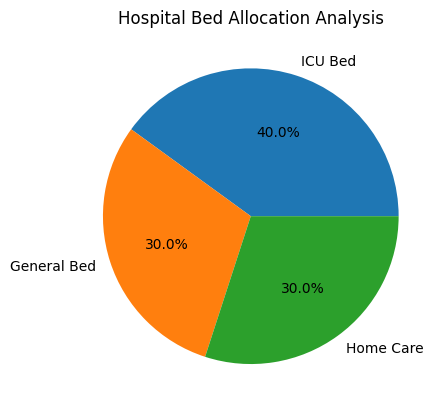

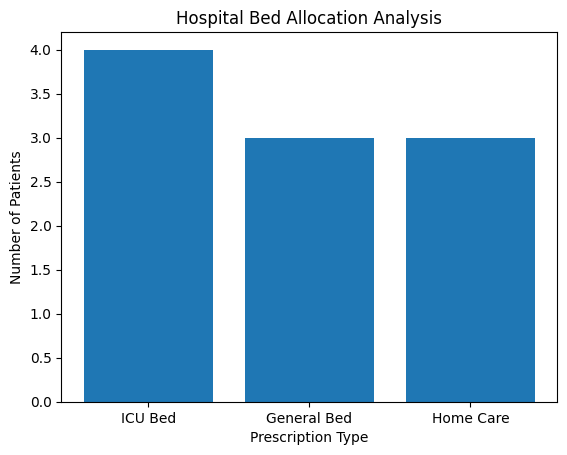

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Name": ["Ravi", "Sita", "Arun", "Kiran", "Meena",
             "Rahul", "Anjali", "Vijay", "Priya", "Lakshmi"],

    "Age": [72, 50, 25, 65, 45, 30, 55, 38, 22, 68],

    "Condition": ["Critical", "Serious", "Stable", "Critical", "Serious",
                  "Stable", "Critical", "Serious", "Stable", "Critical"],

    "Oxygen": [78, 89, 96, 82, 90, 95, 84, 91, 98, 79]
}

df = pd.DataFrame(data)

bed_required = []

for i in range(len(df)):

    if df["Condition"][i] == "Critical" and df["Oxygen"][i] < 85:
        bed_required.append("ICU Bed")

    elif df["Condition"][i] == "Serious" and df["Oxygen"][i] <= 92:
        bed_required.append("General Bed")

    else:
        bed_required.append("Home Care")

df["Prescription"] = bed_required

print(df)

print("\nPrescription Analysis\n")

for i in range(len(df)):
    print(df["Name"][i], "->", df["Prescription"][i])

counts = df["Prescription"].value_counts()


plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
plt.title("Hospital Bed Allocation Analysis")
plt.show()

plt.bar(counts.index, counts.values)
plt.xlabel("Prescription Type")
plt.ylabel("Number of Patients")
plt.title("Hospital Bed Allocation Analysis")
plt.show()